In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [885]:
df = pd.read_csv("data_A.csv")
df.head()

,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0xa658,CUS_0x936d,March,Alistair Barrs,8466,703-48-3482,_______,100433.58,8074.465000,...,Good,1023.93,33.471395,20 Years and 5 Months,No,100.163466,758.0704866746678,Low_spent_Medium_value_payments,229.21254743638283,Standard
1,1,0x6739,CUS_0x9a29,August,Phila,25,339-28-0072,Developer,33119.82,3024.985000,...,Bad,2545.0,33.810567,14 Years and 8 Months,Yes,111.422702,NaN,Low_spent_Small_value_payments,370.6074980582689,Poor
2,2,0xdcf5,CUS_0x12a9,April,Driverb,44,583-20-9758,_______,44822.21,3555.184167,...,Good,730.64,31.145739,23 Years and 10 Months,NM,135.044286,256.4742969677053,Low_spent_Medium_value_payments,243.99983412342044,Standard
3,3,0x14453,CUS_0x3bad,June,Prasadc,29,510-25-2095,Musician,142081.48,11771.123333,...,Standard,932.32,28.409526,27 Years and 0 Months,No,180.616478,423.96126196668365,Low_spent_Small_value_payments,862.534593039876,Standard
4,4,0x1198e,CUS_0xa3e1,January,Poornimai,45,943-92-4350,Scientist,19267.27_,1374.605833,...,Bad,3777.55,28.373426,10 Years and 3 Months,Yes,78.954825,133.56850235207634,Low_spent_Small_value_payments,214.93725572483646,Poor


In [886]:
df.drop(columns=['Unnamed: 0','ID','Customer_ID','Name','SSN'], inplace=True)

In [887]:
cat = ['Month','Occupation','Type_of_Loan','Credit_Mix','Credit_History_Age','Payment_of_Min_Amount','Payment_Behaviour']

In [888]:
num = [
    'Age', 
    'Annual_Income', 
    'Monthly_Inhand_Salary', 
    'Num_Bank_Accounts', 
    'Num_Credit_Card', 
    'Interest_Rate', 
    'Num_of_Loan', 
    'Delay_from_due_date', 
    'Num_of_Delayed_Payment', 
    'Changed_Credit_Limit', 
    'Num_Credit_Inquiries', 
    'Outstanding_Debt', 
    'Credit_Utilization_Ratio', 
    'Total_EMI_per_month', 
    'Amount_invested_monthly', 
    'Monthly_Balance', 
    'Paid_Early', 
    'Credit_History_Months'
]

In [889]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     25000 non-null  object 
 1   Age                       25000 non-null  object 
 2   Occupation                25000 non-null  object 
 3   Annual_Income             25000 non-null  object 
 4   Monthly_Inhand_Salary     21417 non-null  float64
 5   Num_Bank_Accounts         25000 non-null  int64  
 6   Num_Credit_Card           25000 non-null  int64  
 7   Interest_Rate             25000 non-null  int64  
 8   Num_of_Loan               25000 non-null  object 
 9   Type_of_Loan              22172 non-null  object 
 10  Delay_from_due_date       25000 non-null  int64  
 11  Num_of_Delayed_Payment    23267 non-null  object 
 12  Changed_Credit_Limit      25000 non-null  object 
 13  Num_Credit_Inquiries      24494 non-null  float64
 14  Credit

In [890]:
df['Monthly_Balance'].value_counts()

Monthly_Balance
__-333333333333333333333333333__    4
229.21254743638283                  1
272.6303229988156                   1
302.342496594954                    1
379.3033587622674                   1
                                   ..
375.2444974908889                   1
259.2510584469649                   1
372.83106040260833                  1
223.98703472477916                  1
176.86098522197787                  1
Name: count, Length: 24708, dtype: int64

In [891]:
error_cols = ['Age','Annual_Income','Num_of_Loan','Num_of_Delayed_Payment','Outstanding_Debt','Monthly_Balance','Amount_invested_monthly','Changed_Credit_Limit']

for cols in error_cols:
    df[cols] = df[cols] .str.replace('_', '', regex=False).replace('', np.nan)
    df[cols] = pd.to_numeric(df[cols], errors='coerce')

In [892]:
for cols in error_cols:
    print(df[cols].value_counts())

Age
38      780
26      772
27      738
36      735
28      732
       ... 
573       1
6366      1
8246      1
2334      1
6197      1
Name: count, Length: 473, dtype: int64
Annual_Income
72524.200     7
105239.460    7
29764.370     7
50787.690     7
13499.855     7
             ..
20415.520     1
116742.540    1
15948.285     1
7711.540      1
32130.510     1
Name: count, Length: 11466, dtype: int64
Num_of_Loan
2       3725
3       3714
4       3676
0       2702
1       2639
        ... 
54         1
1131       1
227        1
548        1
1382       1
Name: count, Length: 117, dtype: int64
Num_of_Delayed_Payment
19.0      1400
16.0      1381
17.0      1341
18.0      1320
10.0      1319
          ... 
3212.0       1
3402.0       1
2142.0       1
758.0        1
1411.0       1
Name: count, Length: 208, dtype: int64
Outstanding_Debt
460.46     10
1154.86     9
1812.46     8
1421.95     8
1412.35     8
           ..
444.77      1
2558.70     1
912.94      1
33.25       1
1233.41     1
Na

In [893]:
#pip install sweetviz

In [894]:
# import sweetviz as sv
# report = sv.analyze(df)
# report.show_html("eda_report.html")

In [895]:
df.isnull().sum()

Month                          0
Age                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary       3583
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Type_of_Loan                2828
Delay_from_due_date            0
Num_of_Delayed_Payment      1733
Changed_Credit_Limit         518
Num_Credit_Inquiries         506
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age          2249
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     1164
Payment_Behaviour              0
Monthly_Balance              289
Credit_Score                   0
dtype: int64

In [896]:
df.duplicated().sum()

np.int64(0)

In [897]:
(df['Age'] < 0).sum()

np.int64(226)

In [898]:
(df['Age'] > 100).sum()

np.int64(440)

In [899]:
df = df[(df['Age'] > 0) & (df['Age'] <= 100)]

In [900]:
df['Occupation'].value_counts()

Occupation
_______          1728
Engineer         1607
Lawyer           1584
Architect        1562
Media_Manager    1534
Entrepreneur     1526
Accountant       1526
Scientist        1512
Developer        1510
Teacher          1504
Mechanic         1479
Doctor           1479
Journalist       1477
Manager          1445
Musician         1440
Writer           1421
Name: count, dtype: int64

In [901]:
df['Occupation'] = df['Occupation'].replace('_______', 'Unknown')

In [902]:
(df['Annual_Income'] < 0).sum()

np.int64(0)

In [903]:
df['Annual_Income'].describe()

count    2.433400e+04
mean     1.907335e+05
std      1.523971e+06
min      7.005930e+03
25%      1.956959e+04
50%      3.781397e+04
75%      7.309984e+04
max      2.418881e+07
Name: Annual_Income, dtype: float64

In [904]:
df['Annual_Income'].sort_values(ascending=False).head(20)

292      24188807.0
22904    23871966.0
9192     23834698.0
13787    23822065.0
1515     23743065.0
2336     23713472.0
5161     23589996.0
23522    23565022.0
10110    23550326.0
22831    23385723.0
9284     23198518.0
23471    23181767.0
9866     23150353.0
7332     22705379.0
6459     22644332.0
12766    22641761.0
5987     22598167.0
8641     22579073.0
18228    22477833.0
14767    22378557.0
Name: Annual_Income, dtype: float64

In [905]:
df = df[df['Num_Bank_Accounts'] > 0]

In [906]:
df['Num_Bank_Accounts'].describe()

count    23298.000000
mean        17.913126
std        120.560127
min          1.000000
25%          4.000000
50%          6.000000
75%          8.000000
max       1798.000000
Name: Num_Bank_Accounts, dtype: float64

In [907]:
(df['Num_Bank_Accounts'] > 20).sum()

np.int64(324)

In [908]:
df = df[df['Num_Bank_Accounts'] <= 20]

In [909]:
df['Num_Credit_Card'].describe()

count    22974.000000
mean        22.489162
std        128.644414
min          0.000000
25%          4.000000
50%          6.000000
75%          7.000000
max       1499.000000
Name: Num_Credit_Card, dtype: float64

In [910]:
(df['Num_Credit_Card'] > 20).sum()

np.int64(526)

In [911]:
df['Num_Credit_Card'].quantile(0.99)

np.float64(841.0)

In [912]:
df[df['Num_Credit_Card'] > 20]['Num_Credit_Card'].sort_values().unique()

array([  21,   22,   25,   27,   28,   29,   31,   39,   43,   48,   51,
         58,   61,   66,   76,   77,   81,   82,   83,   92,   96,   98,
         99,  104,  106,  109,  110,  112,  115,  118,  121,  122,  123,
        126,  129,  130,  132,  136,  141,  143,  147,  150,  153,  155,
        157,  158,  159,  172,  173,  174,  180,  183,  190,  191,  192,
        195,  197,  212,  218,  221,  223,  237,  238,  240,  242,  246,
        247,  249,  253,  257,  258,  262,  263,  269,  271,  275,  282,
        284,  286,  288,  291,  292,  297,  298,  300,  303,  305,  306,
        308,  309,  311,  320,  322,  326,  327,  331,  332,  336,  340,
        341,  343,  344,  345,  362,  363,  366,  370,  380,  384,  387,
        390,  391,  394,  395,  398,  399,  414,  418,  419,  421,  422,
        427,  434,  444,  446,  450,  451,  455,  457,  458,  461,  463,
        477,  479,  483,  486,  489,  493,  495,  496,  499,  501,  503,
        504,  505,  509,  517,  518,  536,  538,  5

In [913]:
df = df[df['Num_Credit_Card'] <= 30]

In [914]:
df['Interest_Rate'].describe()

count    22455.000000
mean        72.128568
std        466.679646
min          1.000000
25%          8.000000
50%         14.000000
75%         21.000000
max       5775.000000
Name: Interest_Rate, dtype: float64

In [915]:
df.loc[
    df['Interest_Rate'] > 100,
    'Interest_Rate'
] = np.nan

In [916]:
df['Interest_Rate'].quantile([0.95, 0.98, 0.99, 0.995, 0.999])

0.950    32.0
0.980    33.0
0.990    34.0
0.995    34.0
0.999    34.0
Name: Interest_Rate, dtype: float64

In [917]:
df['Num_of_Loan'].describe()

count    22455.000000
mean         3.199466
std         64.391487
min       -100.000000
25%          2.000000
50%          3.000000
75%          5.000000
max       1482.000000
Name: Num_of_Loan, dtype: float64

In [918]:
(df['Num_of_Loan'] < 0).sum()

np.int64(878)

In [919]:
df.loc[df['Num_of_Loan'] < 0,'Num_of_Loan']

28      -100
42      -100
48      -100
54      -100
85      -100
        ... 
24919   -100
24928   -100
24944   -100
24945   -100
24954   -100
Name: Num_of_Loan, Length: 878, dtype: int64

In [920]:
df.loc[
        df['Num_of_Loan'] < 0,
        'Num_of_Loan'
    ] = np.nan

In [921]:
df['Num_of_Loan'].quantile([0.95, 0.98, 0.99, 0.995, 0.999])

0.950       8.000
0.980       9.000
0.990       9.000
0.995       9.000
0.999    1218.664
Name: Num_of_Loan, dtype: float64

In [922]:
df['Type_of_Loan'].value_counts()

Type_of_Loan
Not Specified                                                                                                                                                        295
Personal Loan                                                                                                                                                        281
Credit-Builder Loan                                                                                                                                                  278
Debt Consolidation Loan                                                                                                                                              265
Auto Loan                                                                                                                                                            258
                                                                                                                                              

In [923]:
# df['Loan_Not_Specified'] = (
#     df['Type_of_Loan']
#     .str.contains('Not Specified', na=False)
#     .astype(int)
# )

In [924]:
def clean_loans(text):
    if pd.isna(text):
        return []

    text = text.replace(', and ', ', ')
    text = text.replace(' and ', ', ')

    loans = [loan.strip() for loan in text.split(',')]

    loans = [
        loan for loan in loans
        if loan not in ['', 'Not Specified']
    ]

    loans = list(dict.fromkeys(loans))

    return loans

df['Loan_List'] = df['Type_of_Loan'].apply(clean_loans)

df['Num_Loan_Types'] = df['Loan_List'].apply(len)


In [925]:
df['Loan_Info_Missing'] = (
    df['Type_of_Loan'].isna()
).astype(int)

In [926]:
df['Loan_List'].apply(type).value_counts()

Loan_List
<class 'list'>    22455
Name: count, dtype: int64

In [927]:
df[df['Loan_List'].isna()]

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Loan_List,Num_Loan_Types,Loan_Info_Missing


In [928]:
df['Delay_from_due_date'].describe()

count    22455.000000
mean        21.756045
std         14.941511
min         -5.000000
25%         11.000000
50%         19.000000
75%         29.000000
max         67.000000
Name: Delay_from_due_date, dtype: float64

In [929]:
(df['Delay_from_due_date'] < 0).sum()

np.int64(142)

In [930]:
df[df['Delay_from_due_date'] < 0]['Delay_from_due_date'].value_counts()

Delay_from_due_date
-2    53
-1    43
-3    19
-4    17
-5    10
Name: count, dtype: int64

In [931]:
df['Paid_Early'] = (df['Delay_from_due_date'] < 0).astype(int)
df['Delay_from_due_date'] = df['Delay_from_due_date'].clip(lower=0)

In [932]:
df.loc[
        df['Num_of_Delayed_Payment'] < 0,
        'Num_of_Delayed_Payment'
    ] = np.nan

In [933]:
df['Num_of_Delayed_Payment'].describe()

count    20787.000000
mean        31.222783
std        225.529772
min          0.000000
25%          9.000000
50%         14.000000
75%         19.000000
max       4388.000000
Name: Num_of_Delayed_Payment, dtype: float64

In [934]:
df['Num_of_Delayed_Payment'].quantile([0.95, 0.98, 0.99, 0.993, 0.999])

0.950      24.000
0.980      25.000
0.990      27.000
0.993     540.988
0.999    3886.774
Name: Num_of_Delayed_Payment, dtype: float64

In [935]:
df['Changed_Credit_Limit'].describe()

count    21993.000000
mean        10.581608
std          6.806209
min         -6.430000
25%          5.490000
50%          9.610000
75%         15.190000
max         36.290000
Name: Changed_Credit_Limit, dtype: float64

In [936]:
(df['Num_Credit_Inquiries'] > 50).sum()

np.int64(373)

In [937]:
df['Credit_Mix'] = df['Credit_Mix'].replace('-', 'Unknown')

In [938]:
df['Outstanding_Debt'].describe()

count    22455.000000
mean      1460.781371
std       1169.449624
min          0.340000
25%        581.120000
50%       1197.020000
75%       2033.265000
max       4998.070000
Name: Outstanding_Debt, dtype: float64

In [939]:
df['Credit_History_Age'].head()

1     14 Years and 8 Months
2    23 Years and 10 Months
3     27 Years and 0 Months
4     10 Years and 3 Months
5    29 Years and 11 Months
Name: Credit_History_Age, dtype: object

In [940]:
temp = df['Credit_History_Age'].str.extract(
    r'(\d+)\s+Years?\s+and\s+(\d+)\s+Months?'
)

df['Credit_History_Months'] = (
    temp[0].astype(float) * 12 +
    temp[1].astype(float)
)

df['Credit_History_Months'].head()

df.drop(columns=['Credit_History_Age'], inplace=True)

In [941]:
df['Credit_History_Months'].isna().sum()

np.int64(2037)

In [942]:
df['Total_EMI_per_month'].describe(
    percentiles=[0.90, 0.95, 0.98, 0.995, 0.999]
)

count    22455.000000
mean      1400.047808
std       8255.832999
min          0.000000
50%         71.339076
90%        289.472305
95%        432.522649
98%      30145.120000
99.5%    67553.060000
99.9%    79349.882000
max      82236.000000
Name: Total_EMI_per_month, dtype: float64

In [943]:
(df['Total_EMI_per_month'] > 1000).sum()

np.int64(772)

In [944]:
df['EMI_to_Salary'] = (
    df['Total_EMI_per_month'] /
    df['Monthly_Inhand_Salary']
)

df['EMI_to_Salary'].describe()

count    19232.000000
mean         0.603672
std          4.816399
min          0.000000
25%          0.013208
50%          0.026040
75%          0.043513
max        139.061225
Name: EMI_to_Salary, dtype: float64

In [945]:
#df.loc[df['EMI_to_Salary'] > 2, 'Total_EMI_per_month'] = np.nan

In [946]:
df['Amount_invested_monthly'].describe()


count    21416.000000
mean       626.121943
std       2021.194396
min          0.000000
25%         73.638551
50%        135.087504
75%        263.356666
max      10000.000000
Name: Amount_invested_monthly, dtype: float64

In [947]:
df['Payment_Behaviour'].value_counts()

Payment_Behaviour
Low_spent_Small_value_payments      5697
High_spent_Medium_value_payments    3928
Low_spent_Medium_value_payments     3168
High_spent_Large_value_payments     3020
High_spent_Small_value_payments     2574
Low_spent_Large_value_payments      2393
!@9#%8                              1675
Name: count, dtype: int64

In [948]:
df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8','Unknown')

In [949]:
df['Monthly_Balance'].describe()

count    2.219300e+04
mean    -6.007900e+22
std      4.474777e+24
min     -3.333333e+26
25%      2.692926e+02
50%      3.341171e+02
75%      4.633021e+02
max      1.555201e+03
Name: Monthly_Balance, dtype: float64

In [950]:
df.loc[df['Monthly_Balance'] < 0,'Monthly_Balance'] = np.nan

In [951]:
df.drop(columns=['EMI_to_Salary'],inplace=True)

In [952]:
score_map = {
    'Poor': 0,
    'Standard': 1,
    'Good': 2
}

df['Credit_Score'] = df['Credit_Score'].map(score_map)

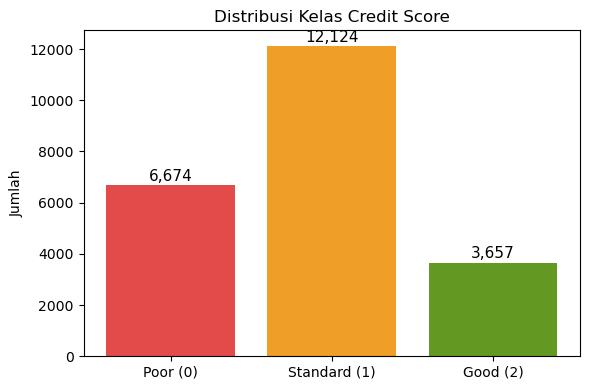

Class balance (%):
Credit_Score
1    54.0
0    29.7
2    16.3
Name: proportion, dtype: float64


In [953]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['Credit_Score'].value_counts().sort_index()
labels = ['Poor (0)', 'Standard (1)', 'Good (2)']
bars = ax.bar(labels, counts.values, color=['#E24B4A', '#EF9F27', '#639922'])
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom', fontsize=11)
ax.set_title('Distribusi Kelas Credit Score')
ax.set_ylabel('Jumlah')
plt.tight_layout()
plt.show()
print(f'Class balance (%):\n{(df["Credit_Score"].value_counts(normalize=True)*100).round(1)}')

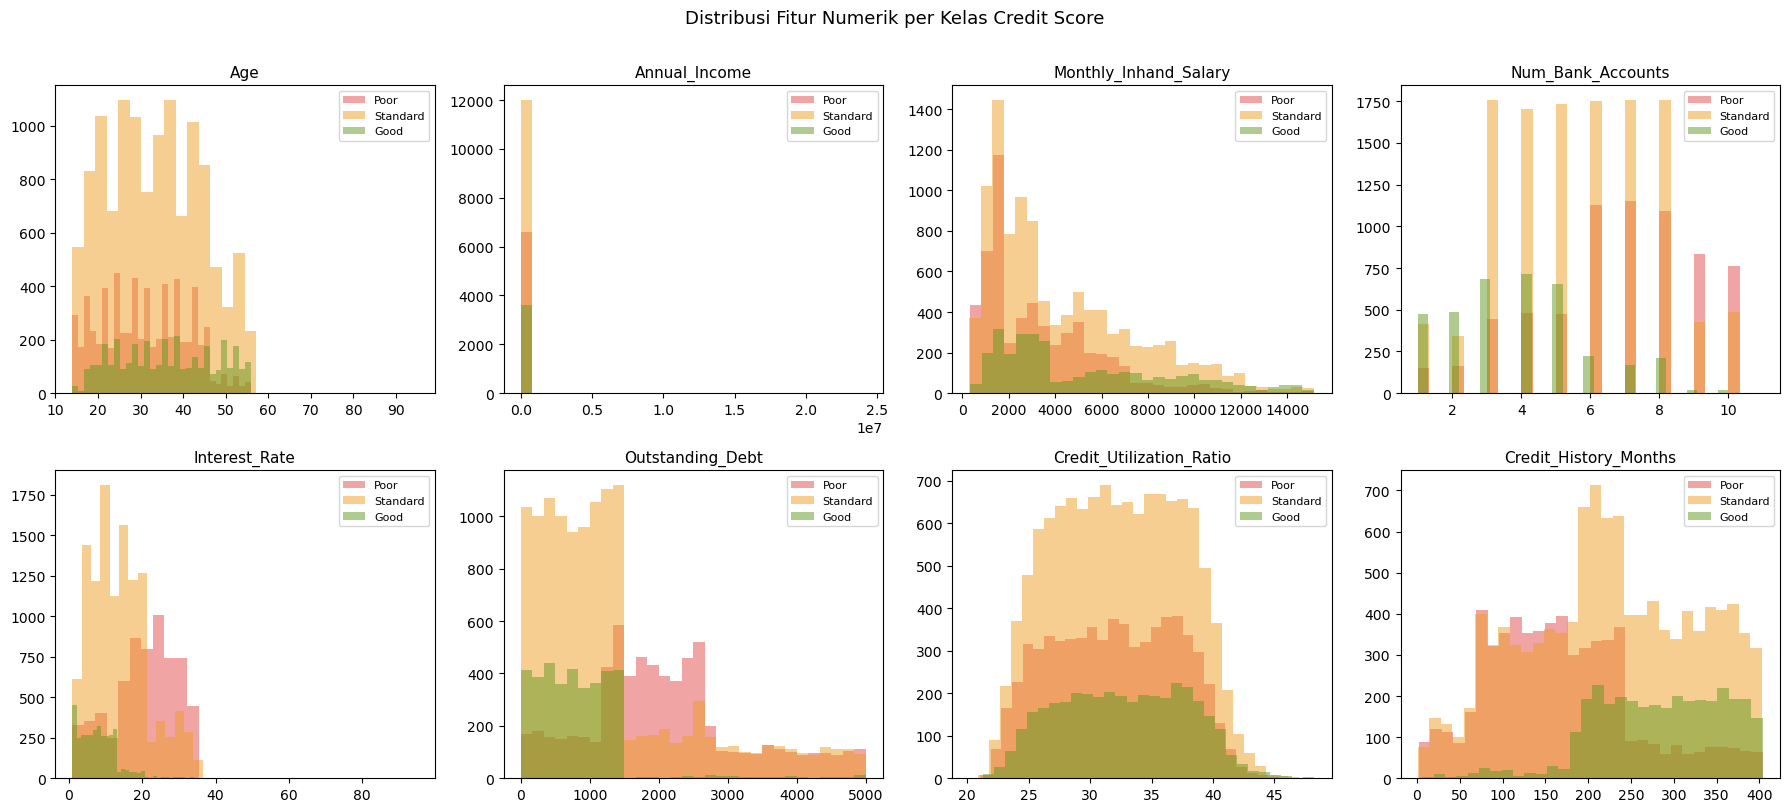

In [954]:
num_features = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary',
    'Num_Bank_Accounts', 'Interest_Rate', 'Outstanding_Debt',
    'Credit_Utilization_Ratio', 'Credit_History_Months'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
class_labels = {0: 'Poor', 1: 'Standard', 2: 'Good'}
colors = {0: '#E24B4A', 1: '#EF9F27', 2: '#639922'}

for i, feat in enumerate(num_features):
    ax = axes[i]
    for cls in [0, 1, 2]:
        data_cls = df[df['Credit_Score'] == cls][feat].dropna()
        ax.hist(data_cls, bins=30, alpha=0.5, label=class_labels[cls], color=colors[cls])
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

plt.suptitle('Distribusi Fitur Numerik per Kelas Credit Score', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

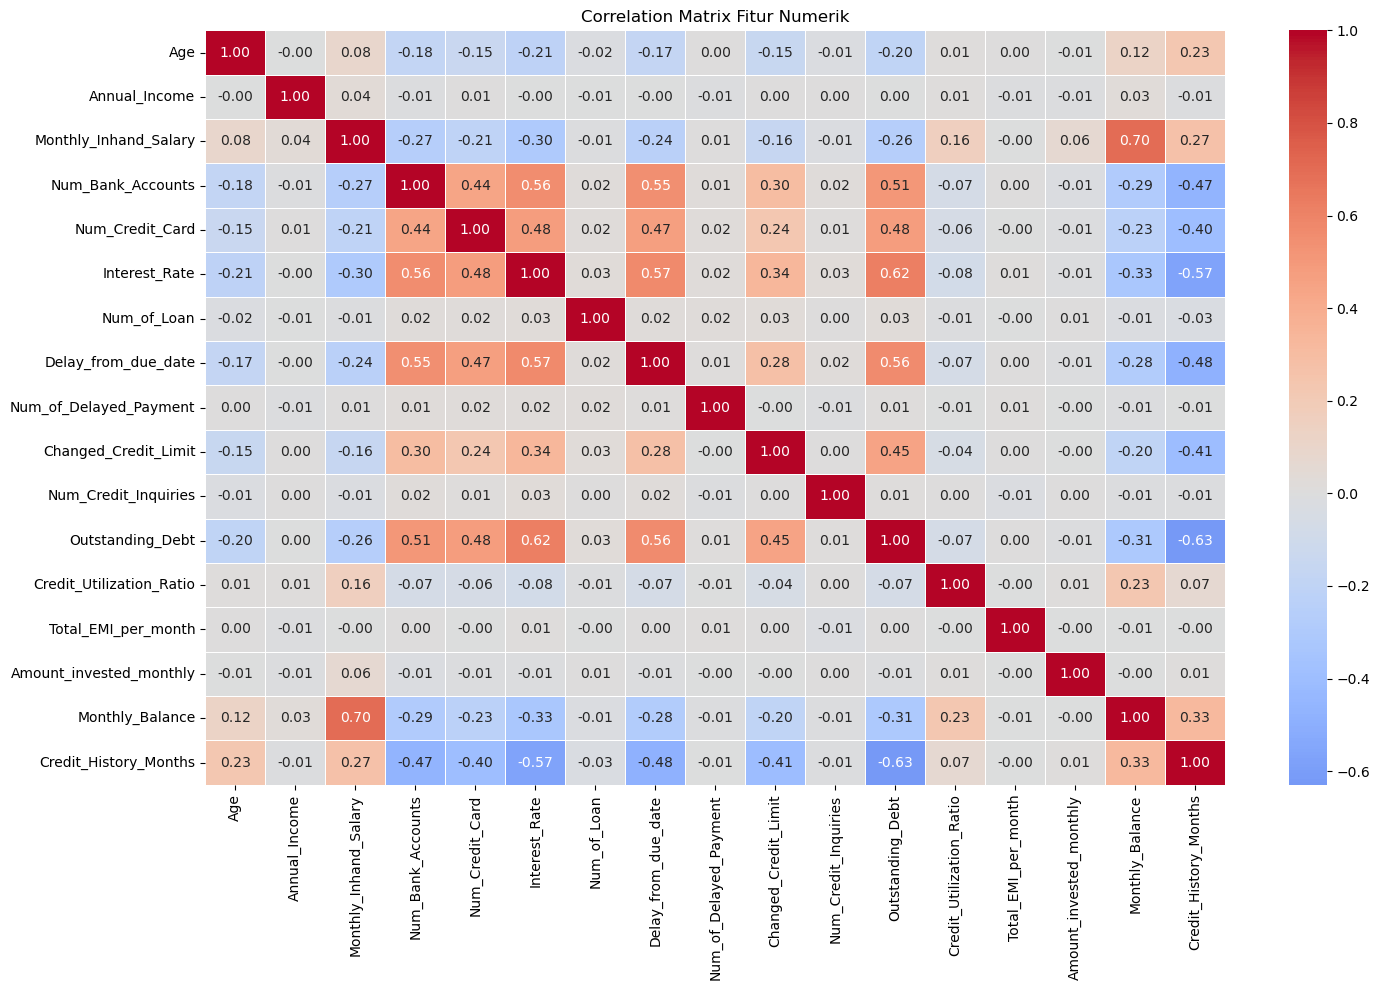

In [955]:
num_cols = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
    'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries',
    'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month',
    'Amount_invested_monthly', 'Monthly_Balance', 'Credit_History_Months'
]

corr = df[num_cols].corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix Fitur Numerik')
plt.tight_layout()
plt.show()

In [956]:
from sklearn.model_selection import train_test_split

x = df.drop(columns=['Credit_Score'])
y = df['Credit_Score']

x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [957]:
x_train.isnull().sum()

Month                          0
Age                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary       2598
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                346
Num_of_Loan                  699
Type_of_Loan                1925
Delay_from_due_date            0
Num_of_Delayed_Payment      1331
Changed_Credit_Limit         374
Num_Credit_Inquiries         348
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly      833
Payment_Behaviour              0
Monthly_Balance              217
Loan_List                      0
Num_Loan_Types                 0
Loan_Info_Missing              0
Paid_Early                     0
Credit_History_Months       1631
dtype: int64

In [958]:
ratio = df['Monthly_Inhand_Salary'] / (df['Annual_Income'] / 12)
ratio.describe()

count    19232.000000
mean         0.988641
std          0.139421
min          0.000259
25%          0.956442
50%          0.998271
75%          1.039827
max          1.473734
dtype: float64

In [959]:
for data in [x_train, x_val, x_test]:
    mask = data['Monthly_Inhand_Salary'].isna()

    data.loc[mask, 'Monthly_Inhand_Salary'] = (
        data.loc[mask, 'Annual_Income'] / 12
    )

In [960]:
median1 = x_train['Num_of_Delayed_Payment'].median()

for data in [x_train, x_val, x_test]:
    data['Num_of_Delayed_Payment'] = (
        data['Num_of_Delayed_Payment']
        .fillna(median1)
    )

In [961]:
median_ir = x_train['Interest_Rate'].median()

for data in [x_train, x_val, x_test]:
    data['Interest_Rate'] = (
        data['Interest_Rate']
        .fillna(median_ir)
    )

In [962]:
median2 = x_train['Num_Credit_Inquiries'].median()

for data in [x_train, x_val, x_test]:
    data['Num_Credit_Inquiries'] = (
        data['Num_Credit_Inquiries']
        .fillna(median2)
    )

In [963]:
median3 = x_train['Credit_History_Months'].median()

for data in [x_train, x_val, x_test]:
    data['Credit_History_Months'] = (
        data['Credit_History_Months']
        .fillna(median3)
    )

In [964]:
median4 = x_train['Amount_invested_monthly'].median()

for data in [x_train, x_val, x_test]:
    data['Amount_invested_monthly'] = (
        data['Amount_invested_monthly']
        .fillna(median4)
    )

In [965]:
median5 = x_train['Monthly_Balance'].median()

for data in [x_train, x_val, x_test]:
    data['Monthly_Balance'] = (
        data['Monthly_Balance']
        .fillna(median5)
    )

In [966]:
median6 = x_train['Changed_Credit_Limit'].median()

for data in [x_train, x_val, x_test]:
    data['Changed_Credit_Limit'] = (
        data['Changed_Credit_Limit']
        .fillna(median6)
    )

In [967]:
median7 = x_train['Num_of_Loan'].median()

for data in [x_train, x_val, x_test]:
    data['Num_of_Loan'] = (
        data['Num_of_Loan']
        .fillna(median7)
    )

In [968]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

train_encoded = pd.DataFrame(
    mlb.fit_transform(x_train['Loan_List']),
    columns=mlb.classes_,
    index=x_train.index
)

val_encoded = pd.DataFrame(
    mlb.transform(x_val['Loan_List']),
    columns=mlb.classes_,
    index=x_val.index
)

test_encoded = pd.DataFrame(
    mlb.transform(x_test['Loan_List']),
    columns=mlb.classes_,
    index=x_test.index
)

In [969]:
x_train = pd.concat([x_train, train_encoded], axis=1)
x_val = pd.concat([x_val, val_encoded], axis=1)
x_test = pd.concat([x_test, test_encoded], axis=1)

In [970]:
drop_cols = [
    'Type_of_Loan',
    'Loan_List'
]

x_train.drop(columns=drop_cols, inplace=True)
x_val.drop(columns=drop_cols, inplace=True)
x_test.drop(columns=drop_cols, inplace=True)

In [971]:
def drop_outliers_quantile(X, y, cols, q=0.99):
    """Hapus baris di training set yang melebihi kuantil q pada kolom cols."""
    mask = pd.Series(True, index=X.index)
    for col in cols:
        upper = X[col].quantile(q)
        mask &= (X[col] <= upper)
    return X[mask], y[mask]

outlier_cols = ['Num_of_Loan', 'Num_of_Delayed_Payment']
x_train, y_train = drop_outliers_quantile(x_train, y_train, outlier_cols, q=0.99)
print(f'Train rows setelah outlier removal: {len(x_train):,}')

Train rows setelah outlier removal: 17,735


In [972]:
x_train['Num_of_Loan'].describe(
    percentiles=[0.90, 0.95, 0.98, 0.995, 0.999]
)

count    17735.000000
mean         3.612067
std          2.414187
min          0.000000
50%          3.000000
90%          7.000000
95%          8.000000
98%          9.000000
99.5%        9.000000
99.9%        9.000000
max          9.000000
Name: Num_of_Loan, dtype: float64

In [973]:
map_month = {
    'January': 1,
    'February': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June': 6,
    'July': 7,
    'August': 8
}
for data in [x_train, x_val, x_test]:
    data['Month'] = data['Month'].map(map_month)

In [974]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    sparse_output=False
)

# Fit HANYA pada training set
ohe.fit(x_train[['Occupation', 'Payment_Behaviour','Credit_Mix','Payment_of_Min_Amount']])

# Transform semuanya
train_encoded = ohe.transform(x_train[['Occupation', 'Payment_Behaviour','Credit_Mix','Payment_of_Min_Amount']])
val_encoded = ohe.transform(x_val[['Occupation', 'Payment_Behaviour','Credit_Mix','Payment_of_Min_Amount']])
test_encoded = ohe.transform(x_test[['Occupation', 'Payment_Behaviour','Credit_Mix','Payment_of_Min_Amount']])

In [975]:

feature_names = ohe.get_feature_names_out(
    ['Occupation', 'Payment_Behaviour','Credit_Mix','Payment_of_Min_Amount']
)

train_encoded = pd.DataFrame(
    train_encoded,
    columns=feature_names,
    index=x_train.index
)

val_encoded = pd.DataFrame(
    val_encoded,
    columns=feature_names,
    index=x_val.index
)

test_encoded = pd.DataFrame(
    test_encoded,
    columns=feature_names,
    index=x_test.index
)

In [976]:
x_train = x_train.drop(
    columns=['Occupation', 'Payment_Behaviour','Credit_Mix','Payment_of_Min_Amount']
)

x_val = x_val.drop(
    columns=['Occupation', 'Payment_Behaviour','Credit_Mix','Payment_of_Min_Amount']
)

x_test = x_test.drop(
    columns=['Occupation', 'Payment_Behaviour','Credit_Mix','Payment_of_Min_Amount']
)

In [977]:
x_train = pd.concat(
    [x_train, train_encoded],
    axis=1
)

x_val = pd.concat(
    [x_val, val_encoded],
    axis=1
)

x_test = pd.concat(
    [x_test, test_encoded],
    axis=1
)

In [978]:
log_cols = ['Annual_Income', 'Amount_invested_monthly', 'Total_EMI_per_month']

print('Skewness sebelum log transform:')
for col in log_cols:
    print(f'  {col}: {x_train[col].skew():.2f}')

for col in log_cols:
    x_train[col] = np.log1p(x_train[col])
    x_val[col]   = np.log1p(x_val[col])
    x_test[col]  = np.log1p(x_test[col])

print('\nSkewness setelah log transform:')
for col in log_cols:
    print(f'  {col}: {x_train[col].skew():.2f}')

Skewness sebelum log transform:
  Annual_Income: 11.90
  Amount_invested_monthly: 4.50
  Total_EMI_per_month: 7.09

Skewness setelah log transform:


  Annual_Income: 1.95
  Amount_invested_monthly: 1.32
  Total_EMI_per_month: 0.20


In [979]:
x_train.isnull().sum()

Month                                                 0
Age                                                   0
Annual_Income                                         0
Monthly_Inhand_Salary                                 0
Num_Bank_Accounts                                     0
Num_Credit_Card                                       0
Interest_Rate                                         0
Num_of_Loan                                           0
Delay_from_due_date                                   0
Num_of_Delayed_Payment                                0
Changed_Credit_Limit                                  0
Num_Credit_Inquiries                                  0
Outstanding_Debt                                      0
Credit_Utilization_Ratio                              0
Total_EMI_per_month                                   0
Amount_invested_monthly                               0
Monthly_Balance                                       0
Num_Loan_Types                                  

In [980]:
x_val.isnull().sum()

Month                                                 0
Age                                                   0
Annual_Income                                         0
Monthly_Inhand_Salary                                 0
Num_Bank_Accounts                                     0
Num_Credit_Card                                       0
Interest_Rate                                         0
Num_of_Loan                                           0
Delay_from_due_date                                   0
Num_of_Delayed_Payment                                0
Changed_Credit_Limit                                  0
Num_Credit_Inquiries                                  0
Outstanding_Debt                                      0
Credit_Utilization_Ratio                              0
Total_EMI_per_month                                   0
Amount_invested_monthly                               0
Monthly_Balance                                       0
Num_Loan_Types                                  

In [981]:
#pip install xgboost catboost

In [982]:
#pip install lightgbm

In [983]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

models = {
    "XGB": XGBClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Catboost": CatBoostClassifier(),
    "lgbm": LGBMClassifier()
    # TODO: Train and evaluate multiple models
}

val_preds = {}
# Train and evaluate each model
for name, model in models.items():
    print(f"\n{'-'*50}")
    print(f"Training {name}...")

    # Train model
    model.fit(x_train, y_train)
    val_preds[name] = model.predict(x_val)
    print(f'  Done.')



--------------------------------------------------
Training XGB...
  Done.

--------------------------------------------------
Training Random Forest...
  Done.

--------------------------------------------------
Training Catboost...
Learning rate set to 0.091625
0:	learn: 1.0411135	total: 25.6ms	remaining: 25.6s
1:	learn: 0.9911441	total: 36.6ms	remaining: 18.3s
2:	learn: 0.9505171	total: 44.9ms	remaining: 14.9s
3:	learn: 0.9182838	total: 55.6ms	remaining: 13.8s
4:	learn: 0.8915041	total: 65.8ms	remaining: 13.1s
5:	learn: 0.8694211	total: 75.5ms	remaining: 12.5s
6:	learn: 0.8471166	total: 87.9ms	remaining: 12.5s
7:	learn: 0.8282729	total: 99.7ms	remaining: 12.4s
8:	learn: 0.8112917	total: 114ms	remaining: 12.6s
9:	learn: 0.7959078	total: 167ms	remaining: 16.5s
10:	learn: 0.7833099	total: 197ms	remaining: 17.7s
11:	learn: 0.7716672	total: 220ms	remaining: 18.1s
12:	learn: 0.7611122	total: 235ms	remaining: 17.8s
13:	learn: 0.7520004	total: 246ms	remaining: 17.3s
14:	learn: 0.7443733	to

In [984]:
def evaluate(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='weighted')
    print(f'{name}')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  F1 (weighted): {f1:.4f}')
    print(classification_report(y_true, y_pred,
          target_names=['Poor','Standard','Good']))
    print('-' * 50)
    return acc, f1

results = {}
for name, pred in val_preds.items():
    acc, f1 = evaluate(y_val, pred, name)
    results[name] = {'accuracy': acc, 'f1': f1}

XGB
  Accuracy : 0.7354
  F1 (weighted): 0.7339
              precision    recall  f1-score   support

        Poor       0.75      0.68      0.71       667
    Standard       0.76      0.81      0.78      1212
        Good       0.63      0.61      0.62       366

    accuracy                           0.74      2245
   macro avg       0.71      0.70      0.70      2245
weighted avg       0.73      0.74      0.73      2245

--------------------------------------------------
Random Forest
  Accuracy : 0.7630
  F1 (weighted): 0.7623
              precision    recall  f1-score   support

        Poor       0.78      0.71      0.75       667
    Standard       0.78      0.82      0.80      1212
        Good       0.66      0.66      0.66       366

    accuracy                           0.76      2245
   macro avg       0.74      0.73      0.74      2245
weighted avg       0.76      0.76      0.76      2245

--------------------------------------------------
Catboost
  Accuracy : 0.7448
 

In [985]:
print(results)

{'XGB': {'accuracy': 0.7354120267260579, 'f1': 0.7338625235397562}, 'Random Forest': {'accuracy': 0.7630289532293987, 'f1': 0.7623423308855362}, 'Catboost': {'accuracy': 0.7447661469933184, 'f1': 0.7427372978918259}, 'lgbm': {'accuracy': 0.734966592427617, 'f1': 0.733787466032556}}


In [986]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    min_samples_leaf=5,
    n_jobs=-1
)

rf.fit(x_train, y_train)
pred_rf = rf.predict(x_val)

In [987]:
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42
)

xgb.fit(x_train, y_train)
pred_xgb = xgb.predict(x_val)

In [988]:
cat = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='MultiClass',
    verbose=200
)

cat.fit(x_train, y_train)
pred_cat = cat.predict(x_val)

0:	learn: 1.0665534	total: 19.4ms	remaining: 9.67s
200:	learn: 0.6199010	total: 1.88s	remaining: 2.8s
400:	learn: 0.5727710	total: 3.84s	remaining: 949ms
499:	learn: 0.5541160	total: 5.01s	remaining: 0us


In [989]:
def evaluate(y_true, y_pred, name):
    print(name)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("F1:", f1_score(y_true, y_pred, average='weighted'))
    print("-"*30)

evaluate(y_val, pred_rf, "Random Forest")
evaluate(y_val, pred_xgb, "XGBoost")
evaluate(y_val, pred_cat, "CatBoost")


Random Forest
Accuracy: 0.7269487750556793
F1: 0.7270806604108522
------------------------------
XGBoost
Accuracy: 0.7527839643652561
F1: 0.7512909769614312
------------------------------
CatBoost
Accuracy: 0.7269487750556793
F1: 0.7253664305710917
------------------------------


In [990]:
best_model_name = max(results, key=lambda k: results[k]['f1'])
best_model = models[best_model_name]
print(f'Model terbaik (val F1): {best_model_name} → F1 = {results[best_model_name]["f1"]:.4f}')

Model terbaik (val F1): Random Forest → F1 = 0.7623


In [991]:
rf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 10,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 5,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 300,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [992]:
x_train.shape

(17735, 55)

In [993]:
train_pred = rf.predict(x_train)
val_pred = rf.predict(x_val)
test_pred = rf.predict(x_test)

train_f1 = f1_score(y_train, train_pred, average='weighted')
val_f1 = f1_score(y_val, val_pred, average='weighted')
test_f1 = f1_score(y_test, test_pred, average='weighted')

print(f"Train F1: {train_f1:.4f}")
print(f"Val F1:   {val_f1:.4f}")
print(f"Test F1:  {test_f1:.4f}")

Train F1: 0.7805
Val F1:   0.7271
Test F1:  0.7058


In [994]:
y_pred_test = best_model.predict(x_test)

print(f'=== EVALUASI FINAL: {best_model_name} pada Test Set ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_test):.4f}')
print(f'F1 (weighted): {f1_score(y_test, y_pred_test, average="weighted"):.4f}')
print()
print(classification_report(y_test, y_pred_test, target_names=['Poor','Standard','Good']))

=== EVALUASI FINAL: Random Forest pada Test Set ===
Accuracy : 0.7462
F1 (weighted): 0.7460

              precision    recall  f1-score   support

        Poor       0.77      0.72      0.75       668
    Standard       0.77      0.79      0.78      1213
        Good       0.63      0.64      0.63       365

    accuracy                           0.75      2246
   macro avg       0.72      0.72      0.72      2246
weighted avg       0.75      0.75      0.75      2246



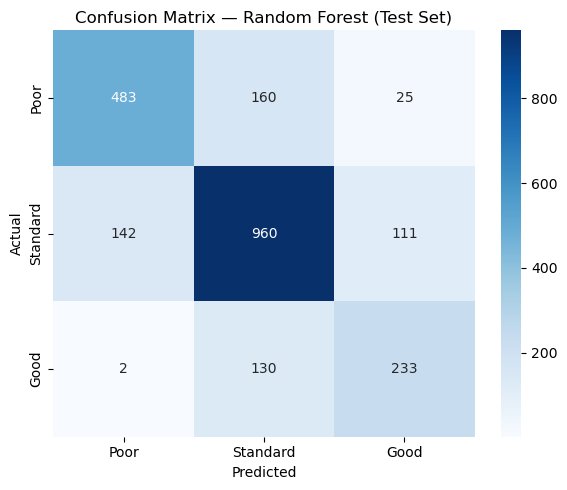

In [995]:
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Poor','Standard','Good'],
            yticklabels=['Poor','Standard','Good'])
plt.title(f'Confusion Matrix — {best_model_name} (Test Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

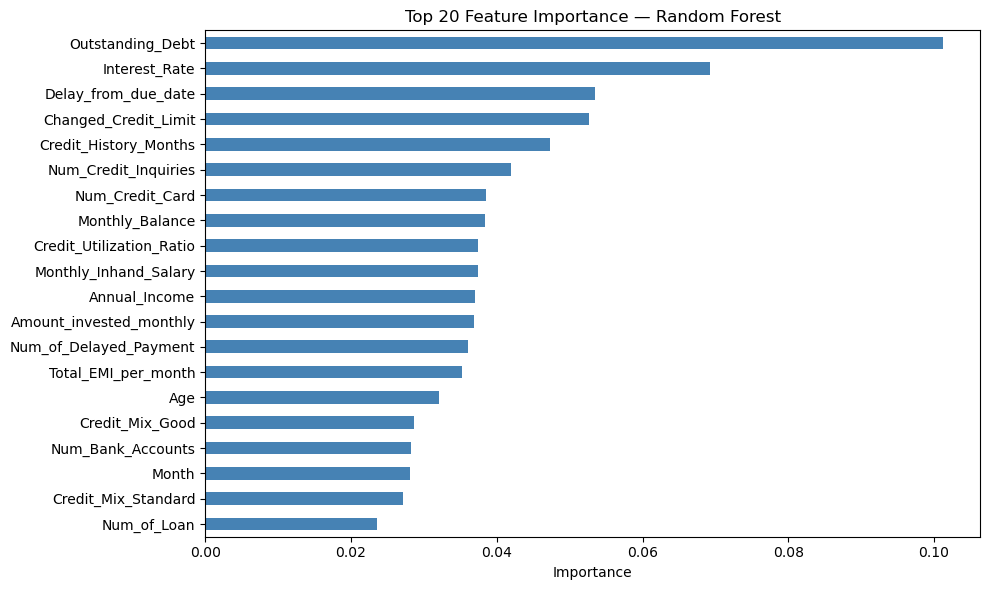

Top 10 features:
Outstanding_Debt            0.1012
Interest_Rate               0.0692
Delay_from_due_date         0.0535
Changed_Credit_Limit        0.0527
Credit_History_Months       0.0472
Num_Credit_Inquiries        0.0419
Num_Credit_Card             0.0385
Monthly_Balance             0.0383
Credit_Utilization_Ratio    0.0375
Monthly_Inhand_Salary       0.0374
dtype: float64


In [996]:
if hasattr(best_model, 'feature_importances_'):
    feat_imp = pd.Series(
        best_model.feature_importances_,
        index=x_train.columns
    ).sort_values(ascending=False)

    top_n = 20
    plt.figure(figsize=(10, 6))
    feat_imp.head(top_n).sort_values().plot(kind='barh', color='steelblue')
    plt.title(f'Top {top_n} Feature Importance — {best_model_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

    print(f'Top 10 features:\n{feat_imp.head(10).round(4)}')
else:
    print('Model tidak mendukung feature_importances_')

In [2]:
import sklearn


In [3]:
print(sklearn.__version__)

1.7.2


In [6]:
pip install scikit-learn==1.7.2

Note: you may need to restart the kernel to use updated packages.


In [5]:
import joblib
model = joblib.load("artifacts/credit_score_pipeline.pkl")
print("loaded")

c:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.3.2 when using version 1.7.2. This might lead to breaking code or in

loaded


c:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
